### 📈 Stock Market Analyzer
 NumPy • Python • OOPs • Data Analysis

# 🚀 Project Overview
A professional stock market analysis system built using NumPy, basic Python, and Object-Oriented Programming concepts.

This project focuses on:
- stock price analysis
- trend detection
- profit/loss calculation
- investment simulation
- risk analysis
- buy/sell recommendation generation
- data visualization

### 🎯 Project Objectives

- Analyze stock market performance using numerical data.
- Implement real-world financial analysis logic.
- Practice NumPy-based data manipulation and analysis.
- Build investment and recommendation systems.
- Visualize stock trends using graphs.
- Apply Python and OOPs concepts in a practical project.

# 🧩 PROJECT STRUCTURE

# 📂 Module 1 — Dataset Management & Preprocessing

## Tasks Performed

- Created stock market dataset
- Structured financial data columns: 
Day, Open Price, High Price, Low Price, Closing Price, Trading Volume.
- Converted dataset into NumPy arrays
- Checked:
  - shape
  - dimensions
  - datatype
  - size

In [1]:
import numpy as np
stock_data = np.array([
    ["Monday", 105, 108, 98, 100, 12000],
    ["Tuesday", 105, 112, 102, 110, 15000],
    ["Wednesday", 110, 115, 107, 110, 17000],
    ["Thursday", 113, 118, 111, 116, 16000],
    ["Friday", 116, 122, 114, 120, 20000],
    ["Saturday", 120, 125, 118, 123, 21000],
    ["Sunday", 120, 128, 121, 100, 23000]
])
print("\n")
print("stock data: \n", stock_data)
print("\n")
print("shape of data: ", stock_data.shape)
print("dimensions of data: ", stock_data.ndim)
print("datatype of data: ", stock_data.dtype)
print("size of data: ", stock_data.size)



stock data: 
 [['Monday' '105' '108' '98' '100' '12000']
 ['Tuesday' '105' '112' '102' '110' '15000']
 ['Wednesday' '110' '115' '107' '110' '17000']
 ['Thursday' '113' '118' '111' '116' '16000']
 ['Friday' '116' '122' '114' '120' '20000']
 ['Saturday' '120' '125' '118' '123' '21000']
 ['Sunday' '120' '128' '121' '100' '23000']]


shape of data:  (7, 6)
dimensions of data:  2
datatype of data:  <U21
size of data:  42


# 📊 Module 2 — Market Performance Analysis

## Tasks Performed
Analysis Performed

- Highest closing price analysis
- Lowest closing price analysis
- Average closing price calculation
- Median closing price calculation
- Highest trading volume detection
- Lowest trading volume detection
- Daily profit/loss analysis
- Percentage price change calculation:- Percentage Price Change tells:
                                                 👉 how much the stock price increased or decreased in percentage (%) between opening price and closing price.It measures the stock’s daily growth or decline.


In [65]:
Highest_closing_price= np.argmax(stock_data[:, 4], axis=0)
print("Highest_closing_price:", stock_data[Highest_closing_price, 4], "on:",stock_data[Highest_closing_price, 0])

Lowest_closing_price= np.argmin(stock_data[:, 4], axis=0)
print("Lowest_closing_price:", stock_data[Lowest_closing_price, 4], "on:",stock_data[Lowest_closing_price, 0])


avg_closing_price= np.mean(stock_data[:,4].astype(int))
print("Average closing price:", avg_closing_price)

median_closing_price= np.median(stock_data[:,4].astype(int))
print("Median closing price Calculation:", median_closing_price)

Highest_trading_price= np.argmax(stock_data[:, 5], axis=0)
print("Highest_tradingvolumne_detection:", stock_data[Highest_trading_price, 5], "on:",stock_data[Highest_trading_price, 0])

Lowest_trading_price= np.argmin(stock_data[:, 5], axis=0)
print("Lowest_tradingvolumne_detection:", stock_data[Lowest_trading_price, 5], "on:",stock_data[Lowest_trading_price, 0])
print("\n")
profit_loss= np.where(stock_data[:,4].astype(int) - stock_data[:,1].astype(int) >0 , 'PROFIT', 
                      np.where(stock_data[:,4].astype(int) - stock_data[:,1].astype(int) <0, 'LOSS', 'NO CHANGE'))

profit_loss_analysis= np.empty((0,2), dtype= str)
for i in range(len(stock_data)):
    profit_loss_analysis= np.append(profit_loss_analysis, [[stock_data[i,0], profit_loss[i]]], axis=0)

print("========== INVESTMENT VALUE ANALYSIS ==========\n")
print(profit_loss_analysis)

closep= stock_data[:,4].astype(float)
openp= stock_data[:,1].astype(float)

per_change= ((closep-openp)/openp) *100

change_analysis= np.where(per_change >0, 'INCREASED',
                          np.where(per_change <0, 'DECREASED', 'NO CHANGE'))

percentage_change_analysis= np.empty((0,3), dtype=object)

for i in range(len(stock_data)):
    percentage_change_analysis= np.append(percentage_change_analysis,
                                           [[stock_data[i,0], change_analysis[i], str(round(per_change[i],2))+ "%"]], 
                                           axis=0)

print("\n")
print("========== INVESTMENT VALUE ANALYSIS ==========\n")
print(percentage_change_analysis)



Highest_closing_price: 123 on: Saturday
Lowest_closing_price: 100 on: Monday
Average closing price: 111.28571428571429
Median closing price Calculation: 110.0
Highest_tradingvolumne_detection: 23000 on: Sunday
Lowest_tradingvolumne_detection: 12000 on: Monday


========== INVESTMENT VALUE ANALYSIS ==========

[['Monday' 'LOSS']
 ['Tuesday' 'PROFIT']
 ['Wednesday' 'NO CHANGE']
 ['Thursday' 'PROFIT']
 ['Friday' 'PROFIT']
 ['Saturday' 'PROFIT']
 ['Sunday' 'LOSS']]


========== INVESTMENT VALUE ANALYSIS ==========

[['Monday' 'DECREASED' '-4.76%']
 ['Tuesday' 'INCREASED' '4.76%']
 ['Wednesday' 'NO CHANGE' '0.0%']
 ['Thursday' 'INCREASED' '2.65%']
 ['Friday' 'INCREASED' '3.45%']
 ['Saturday' 'INCREASED' '2.5%']
 ['Sunday' 'DECREASED' '-16.67%']]


# 📈 Module 3 — Trend Analysis System

# Task Performed
Features Implemented

- Moving average analysis
- Uptrend detection
- Downtrend detection
- Stable trend identification
- Best performing trading day analysis
- Worst performing trading day analysis
- Cumulative return calculation
- Cumulative profit tracking

In [60]:
moving_avg= np.convolve(stock_data[:, 4].astype(int), 
                        np.ones(3)/3,
                        mode= "valid")
print("Moving Average Analysis: \n", np.round(moving_avg))

print("\n")

print("========== TREND DETECTION ==========\n")
for i in range(1,len(stock_data)):
    if(stock_data[i-1, 4].astype(int) > stock_data[i, 4].astype(int)):
        print("DOWNTREND: ", stock_data[i,0])
    
    if(stock_data[i-1, 4].astype(int) < stock_data[i, 4].astype(int)):
        print("UPTREND: ", stock_data[i,0])

    if(stock_data[i-1, 4].astype(int) == stock_data[i, 4].astype(int)):
        print("STABLE TREND: ", stock_data[i,0])

print("\n")
print("========== TRADING ANALYSIS==========\n")
best_day= np.argmax(per_change)
print("BEST TRADING DAY:", stock_data[best_day, 0], " and percentage profit is:", str(round(per_change[best_day],2)) + "%")

worst_day= np.argmin(per_change)
print("WORST TRADING DAY:", stock_data[worst_day, 0], " and percentage profit is:", str(round(per_change[worst_day],2)) + "%")
    

Moving Average Analysis: 
 [107. 112. 115. 120. 114.]


========== TREND DETECTION ==========

UPTREND:  Tuesday
STABLE TREND:  Wednesday
UPTREND:  Thursday
UPTREND:  Friday
UPTREND:  Saturday
DOWNTREND:  Sunday


========== TRADING ANALYSIS==========

BEST TRADING DAY: Tuesday  and percentage profit is: 4.76%
WORST TRADING DAY: Sunday  and percentage profit is: -16.67%


# ⚠️ Module 4 — Risk & Volatility Analysis

## TASK
 Risk Analysis Features

- Standard deviation calculation
- Variance calculation
- Daily volatility analysis
- High-risk day identification
- Low-risk day identification

In [57]:
closing_price= stock_data[:, 4].astype(int)
std_cal= np.std(closing_price)
print("Standard Deviation Calculation: ", round(std_cal,3))

variance= np.var(closing_price)
print("Variance Calculation: ", round(variance,3))

high_price= stock_data[:,2].astype(int)
low_price= stock_data[:,3].astype(int)

volatility= high_price - low_price
print("\n")
print("========== INVESTMENT VALUE ANALYSIS ==========\n")
for i in range(len(volatility)):
    print(stock_data[i,0], " has volatility of", volatility[i])

high_risk= np.argmax(volatility)
low_risk= np.argmin(volatility)
print("\n")

print("========== RISK ANALYSIS ==========\n")
print("High Risk day:- ", stock_data[high_risk,0])
print("Low Risk day:- ", stock_data[low_risk,0])


Standard Deviation Calculation:  8.396
Variance Calculation:  70.49


========== INVESTMENT VALUE ANALYSIS ==========

Monday  has volatility of 10
Tuesday  has volatility of 10
Wednesday  has volatility of 8
Thursday  has volatility of 7
Friday  has volatility of 8
Saturday  has volatility of 7
Sunday  has volatility of 7


========== RISK ANALYSIS ==========

High Risk day:-  Monday
Low Risk day:-  Thursday


# 💰 Module 5 — Investment Simulation System

# Task
Investment Features

- ₹10,000 investment simulation
- Investment growth tracking
- Profit percentage calculation
- Return analysis
- Best investment day detection
- Worst investment day detection

In [ ]:
investment = 10000

starting_stock_price = stock_data[0,4].astype(int)

shares_bought = investment / starting_stock_price

closing_price = stock_data[:,4].astype(int)

investment_value = shares_bought * closing_price

print("========== INVESTMENT VALUE ANALYSIS ==========\n")

for i in range(len(stock_data)):
    print(stock_data[i,0], "investment value is :", investment_value[i])

print("\n")

profit = investment_value - investment

profit_percentage = (profit / investment) * 100

print("========== PROFIT PERCENTAGE ANALYSIS ==========\n")

for i in range(len(stock_data)):
    print(stock_data[i,0], "has", profit_percentage[i], "% return")


best_day= np.argmax(investment_value)
worst_day= np.argmin(investment_value)
print("\n")
print("========== INVESTMENT DAY DETECTION ==========\n")

print("Best investment day: ", stock_data[best_day, 0])
print("Worst investment day: ", stock_data[worst_day, 0])

========== INVESTMENT VALUE ANALYSIS ==========

Monday investment value is : 10000.0
Tuesday investment value is : 11000.0
Wednesday investment value is : 11000.0
Thursday investment value is : 11600.0
Friday investment value is : 12000.0
Saturday investment value is : 12300.0
Sunday investment value is : 10000.0


========== PROFIT PERCENTAGE ANALYSIS ==========

Monday has 0.0 % return
Tuesday has 10.0 % return
Wednesday has 10.0 % return
Thursday has 16.0 % return
Friday has 20.0 % return
Saturday has 23.0 % return
Sunday has 0.0 % return


========== INVESTMENT DAY DETECTION ==========

Best investment day:  Saturday
Worst investment day:  Monday


# 🧠 Module 6 — Buy/Sell Recommendation Engine

# Task performed
Recommendation Logic

- BUY signal generation
- SELL signal generation
- HOLD signal generation

Final Recommendation Categories

- Strong Buy
- Buy
- Hold
- Sell
- Strong Sell

In [71]:

print("========== BUY / SELL / HOLD RECOMMENDATION ENGINE ==========\n")

recommendations = []

for i in range(len(stock_data)):

    if profit_percentage[i] >= 15 and volatility[i] <= 8:
        signal = "Strong Buy"

    elif profit_percentage[i] > 5:
        signal = "Buy"

    elif profit_percentage[i] >= 0 and volatility[i] <= 10:
        signal = "Hold"

    elif profit_percentage[i] > -10:
        signal = "Sell"

    else:
        signal = "Strong Sell"

    recommendations.append(signal)

    print("Day:", stock_data[i, 0])
    print("Profit Percentage:", round(profit_percentage[i], 2), "%")
    print("Volatility:", volatility[i])
    print("Recommendation:", signal)
    print("-----------------------------------------")
recommendations = np.array(recommendations)

print("\nFinal Recommendation Summary:")
print(recommendations)

========== BUY / SELL / HOLD RECOMMENDATION ENGINE ==========

Day: Monday
Profit Percentage: 0.0 %
Volatility: 10
Recommendation: Hold
-----------------------------------------
Day: Tuesday
Profit Percentage: 10.0 %
Volatility: 10
Recommendation: Buy
-----------------------------------------
Day: Wednesday
Profit Percentage: 10.0 %
Volatility: 8
Recommendation: Buy
-----------------------------------------
Day: Thursday
Profit Percentage: 16.0 %
Volatility: 7
Recommendation: Strong Buy
-----------------------------------------
Day: Friday
Profit Percentage: 20.0 %
Volatility: 8
Recommendation: Strong Buy
-----------------------------------------
Day: Saturday
Profit Percentage: 23.0 %
Volatility: 7
Recommendation: Strong Buy
-----------------------------------------
Day: Sunday
Profit Percentage: 0.0 %
Volatility: 7
Recommendation: Hold
-----------------------------------------

Final Recommendation Summary:
['Hold' 'Buy' 'Buy' 'Strong Buy' 'Strong Buy' 'Strong Buy' 'Hold']


#  Module 8 — Data Visualization

# Task Performed
Visualizations Created,
Closing price trend graph,
Trading volume graph,
Moving average graph
Cumulative return graph,
Profit vs loss comparison graph,
Risk vs return analysis graph.

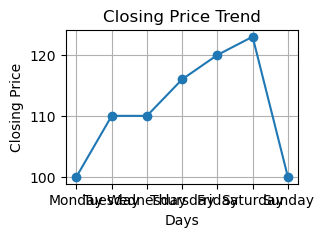

In [77]:
import matplotlib.pyplot as plt

days = stock_data[:, 0]
closing_price = stock_data[:, 4].astype(int)
volume = stock_data[:, 5].astype(int)


plt.figure(figsize=(3, 2))
plt.plot(days, closing_price, marker='o')
plt.title("Closing Price Trend")
plt.xlabel("Days")
plt.ylabel("Closing Price")
plt.grid(True)
plt.show()


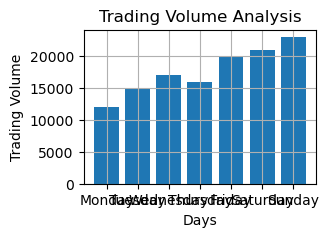

In [78]:
plt.figure(figsize=(3, 2))
plt.bar(days, volume)
plt.title("Trading Volume Analysis")
plt.xlabel("Days")
plt.ylabel("Trading Volume")
plt.grid(True)
plt.show()

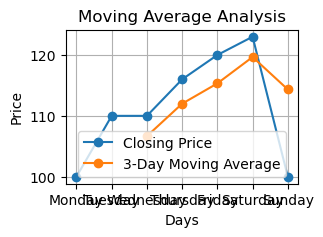

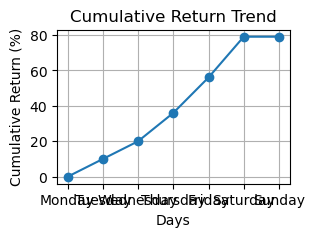

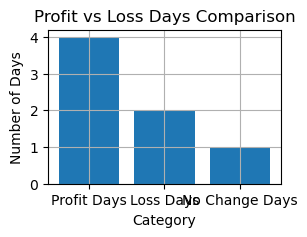

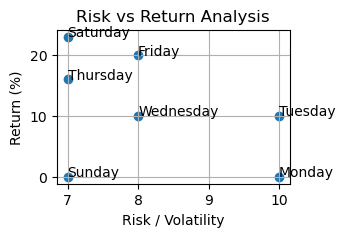

In [79]:

# 1. Moving Average Graph
window = 3
moving_average = np.convolve(closing_price, np.ones(window) / window, mode='valid')
ma_days = days[window-1:]

plt.figure(figsize=(3, 2))
plt.plot(days, closing_price, marker='o', label="Closing Price")
plt.plot(ma_days, moving_average, marker='o', label="3-Day Moving Average")
plt.title("Moving Average Analysis")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


# 2. Cumulative Return Graph
daily_return = ((closing_price - closing_price[0]) / closing_price[0]) * 100
cumulative_return = np.cumsum(daily_return)

plt.figure(figsize=(3, 2))
plt.plot(days, cumulative_return, marker='o')
plt.title("Cumulative Return Trend")
plt.xlabel("Days")
plt.ylabel("Cumulative Return (%)")
plt.grid(True)
plt.show()


# 3. Profit vs Loss Comparison Graph
daily_profit_loss = closing_price - stock_data[:, 1].astype(float)

profit_days = np.sum(daily_profit_loss > 0)
loss_days = np.sum(daily_profit_loss < 0)
no_change_days = np.sum(daily_profit_loss == 0)

categories = ["Profit Days", "Loss Days", "No Change Days"]
values = [profit_days, loss_days, no_change_days]

plt.figure(figsize=(3, 2))
plt.bar(categories, values)
plt.title("Profit vs Loss Days Comparison")
plt.xlabel("Category")
plt.ylabel("Number of Days")
plt.grid(True)
plt.show()


# 4. Risk vs Return Analysis Graph
volatility = stock_data[:, 2].astype(float) - stock_data[:, 3].astype(float)
profit_percentage = ((closing_price - closing_price[0]) / closing_price[0]) * 100

plt.figure(figsize=(3, 2))
plt.scatter(volatility, profit_percentage)

for i in range(len(days)):
    plt.text(volatility[i], profit_percentage[i], str(days[i]))

plt.title("Risk vs Return Analysis")
plt.xlabel("Risk / Volatility")
plt.ylabel("Return (%)")
plt.grid(True)
plt.show()

# 🏗️ Module 9 — OOPs Implementation

# Task Performed
Classes Created,
StockData,
Handles dataset loading and preprocessing.
StockAnalyzer,
Performs stock market analysis operations.
InvestmentSimulator,
Handles investment growth simulation.
RecommendationSystem,
Generates market recommendations.

In [83]:
class StockData:
    def __init__(self, stock_data):
        self.stock_data = stock_data
        self.close_price = stock_data[:,4].astype(float)
        self.high_price = stock_data[:,2].astype(float)
        self.low_price = stock_data[:,3].astype(float)
        self.days = stock_data[:,0]

class StockAnalyzer:
    def __init__(self, data):
        self.data = data
    def market_analysis(self):
        print("Highest Closing Price:",
              np.max(self.data.close_price))
        print("Lowest Closing Price:",
              np.min(self.data.close_price))
        volatility = self.data.high_price - self.data.low_price
        print("Highest Risk Day:",
              self.data.days[np.argmax(volatility)])

class InvestmentSimulator:
    def __init__(self, data):
        self.data = data
    def simulate(self):
        investment = 10000
        shares = investment / self.data.close_price[0]
        investment_value = shares * self.data.close_price
        print("Investment Value:",
              investment_value)

class RecommendationSystem:
    def __init__(self, profit_percentage):
        self.profit_percentage = profit_percentage
    def recommendation(self):
        for i in self.profit_percentage:
            if i > 15:
                print("Strong Buy")
            elif i > 5:
                print("Buy")
            else:
                print("Hold")

# Objects
stock = StockData(stock_data)
analyzer = StockAnalyzer(stock)
analyzer.market_analysis()
simulator = InvestmentSimulator(stock)
simulator.simulate()
profit_percentage = np.array([0,5,12,18])
recommend = RecommendationSystem(profit_percentage)
recommend.recommendation()


Highest Closing Price: 123.0
Lowest Closing Price: 100.0
Highest Risk Day: Monday
Investment Value: [10000. 11000. 11000. 11600. 12000. 12300. 10000.]
Hold
Hold
Buy
Strong Buy
